In [ ]:
library(ieugwasr)
library(TwoSampleMR)
library(dplyr)
library(ggplot2)
chd <- tophits("ieu-a-7")
chd_rep
str(chd)

l <- list()
for(i in 1:nrow(chd)) {
    message(i)
    if(chd$chr[i] == 6 & chd$position[i] > 25000000 & chd$position[i] < 35000000) {
        message("Skipping MHC region")
        next
    }
    l[[i]] <- phewas(chd$rsid[i], pval = 1e-8, batch=c("ukb-b", "ukb-d"))
}
str(l)
phewas_result <- bind_rows(l)

tibble [41 × 12] (S3: tbl_df/tbl/data.frame)
 $ id      : chr [1:41] "ieu-a-7" "ieu-a-7" "ieu-a-7" "ieu-a-7" ...
 $ trait   : chr [1:41] "Coronary heart disease" "Coronary heart disease" "Coronary heart disease" "Coronary heart disease" ...
 $ chr     : chr [1:41] "9" "6" "6" "1" ...
 $ position: int [1:41] 22098619 12903957 161005610 109817192 203893999 79124475 160687412 35593827 11188247 44480811 ...
 $ rsid    : chr [1:41] "rs2891168" "rs9349379" "rs55730499" "rs7528419" ...
 $ ea      : chr [1:41] "G" "G" "T" "G" ...
 $ nea     : chr [1:41] "A" "A" "C" "A" ...
 $ eaf     : num [1:41] 0.4887 0.4316 0.0562 0.2142 0.107 ...
 $ beta    : num [1:41] 0.193 0.132 0.317 -0.115 0.138 ...
 $ se      : num [1:41] 0.00919 0.00965 0.02424 0.01148 0.01583 ...
 $ p       : num [1:41] 2.29e-98 1.81e-42 5.39e-39 1.97e-23 3.12e-18 ...
 $ n       : num [1:41] 184305 184305 184305 184305 184305 ...


1

2

3

4

5

6

7

8

9

10

11

12

13

14

15

16

17

18

19

20

21

22

23

24

25

26

27

28

29

30

31

32

33

34

35

36

37

38

39

40

41



List of 41
 $ : tibble [69 × 12] (S3: tbl_df/tbl/data.frame)
  ..$ id      : chr [1:69] "ukb-d-I9_IHD" "ukb-d-I9_CORATHER" "ukb-b-1668" "ukb-b-18408" ...
  ..$ trait   : chr [1:69] "Ischaemic heart disease, wide definition" "Coronary atherosclerosis" "Diagnoses - main ICD10: I25.1 Atherosclerotic heart disease" "Illnesses of father: Heart disease" ...
  ..$ chr     : chr [1:69] "9" "9" "9" "9" ...
  ..$ position: int [1:69] 22098619 22098619 22098619 22098619 22098619 22098619 22098619 22098619 22098619 22098619 ...
  ..$ rsid    : chr [1:69] "rs2891168" "rs2891168" "rs2891168" "rs2891168" ...
  ..$ ea      : chr [1:69] "G" "G" "G" "G" ...
  ..$ nea     : chr [1:69] "A" "A" "A" "A" ...
  ..$ eaf     : num [1:69] 0.488 0.488 0.49 0.49 0.49 ...
  ..$ beta    : num [1:69] 0.01011 0.00812 0.00586 0.01652 0.00503 ...
  ..$ se      : num [1:69] 0.000537 0.000451 0.00033 0.001037 0.000364 ...
  ..$ p       : num [1:69] 5.36e-79 2.33e-72 2.20e-70 4.10e-57 2.00e-43 ...
  ..$ n       : num [1:69

In [62]:
sbpid <- "ieu-b-5138"
ldlid <- "ukb-d-30780_raw"
# smokingid <- "ieu-b-4877"
smokingid <- "ukb-b-10831"
alcoholid <- "ukb-b-5779"
bmiid <- "ukb-b-2303"

allintids <- c(sbpid, ldlid, smokingid, alcoholid, bmiid)
int_inst <- extract_instruments(allintids)
# outdat <- extract_outcome_data(int_inst$SNP, "ukb-d-I9_IHD")

In [67]:
file_url <- ieugwasr::gwasinfo_files("ukb-d-I9_IHD")
str(file_url)

lapply(file_url$`ukb-d-I9_IHD`, function(url) download.file(url, destfile = basename(url)))


tibble [3 × 1] (S3: tbl_df/tbl/data.frame)
 $ ukb-d-I9_IHD: chr [1:3] "https://ieup4.objectstorage.uk-london-1.oci.customer-oci.com/p/bkbj-TT3jprjbViWkOQOP20ubWrMPvOdfGSXh-iK_potksf3"| __truncated__ "https://ieup4.objectstorage.uk-london-1.oci.customer-oci.com/p/bv1oTLdS10ws9h4Zf1ZBQ4XRMTkS28BVnVrk5zIeLxc7nI2C"| __truncated__ "https://ieup4.objectstorage.uk-london-1.oci.customer-oci.com/p/JP6DZP_i3C_4enxS5WbB-Ox9ZHvOetFWsL8tPcNteH3k7T1A"| __truncated__


[[1]]
[1] 0

[[2]]
[1] 0

[[3]]
[1] 0

In [68]:
library(gwasvcf)
set_bcftools("~/bin/bcftools")
outdat <- query_gwas(rsid = int_inst$SNP, vcf = "ukb-d-I9_IHD.vcf.gz") %>% vcf_to_tibble()
str(outdat)


tibble [988 × 21] (S3: tbl_df/tbl/data.frame)
 $ seqnames    : Factor w/ 84 levels "1","2","3","4",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ start       : int [1:988] 940096 1345970 1601052 1687482 2723214 3327032 4569436 6657424 6693097 10767902 ...
 $ end         : int [1:988] 940096 1345970 1601052 1687482 2723214 3327032 4569436 6657424 6693097 10767902 ...
 $ width       : int [1:988] 1 1 1 1 1 1 1 1 1 1 ...
 $ strand      : Factor w/ 3 levels "+","-","*": 3 3 3 3 3 3 3 3 3 3 ...
 $ paramRangeID: Factor w/ 0 levels: NA NA NA NA NA NA NA NA NA NA ...
 $ REF         : chr [1:988] "C" "A" "G" "G" ...
 $ ALT         : chr [1:988] "T" "G" "A" "T" ...
 $ QUAL        : num [1:988] NA NA NA NA NA NA NA NA NA NA ...
 $ FILTER      : chr [1:988] "PASS" "PASS" "PASS" "PASS" ...
 $ ES          : num [1:988] -1.09e-05 -2.94e-04 -1.57e-03 -1.46e-03 -1.26e-03 ...
 $ SE          : num [1:988] 0.000545 0.00101 0.000621 0.000539 0.000542 ...
 $ LP          : num [1:988] 0.00698 0.11303 1.94505 2.16349 1.69665

In [69]:
outdat <- outdat %>%
    rename(SNP = ID, chr.outcome = seqnames, pos.outcome = start, other_allele.outcome = REF, effect_allele.outcome = ALT, pval.outcome = LP, beta.outcome = ES, se.outcome = SE, sample_size.outcome = SS, id.outcome = id, eaf.outcome = AF) %>%
    mutate(outcome = "CHD")
str(outdat)

tibble [988 × 22] (S3: tbl_df/tbl/data.frame)
 $ chr.outcome          : Factor w/ 84 levels "1","2","3","4",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ pos.outcome          : int [1:988] 940096 1345970 1601052 1687482 2723214 3327032 4569436 6657424 6693097 10767902 ...
 $ end                  : int [1:988] 940096 1345970 1601052 1687482 2723214 3327032 4569436 6657424 6693097 10767902 ...
 $ width                : int [1:988] 1 1 1 1 1 1 1 1 1 1 ...
 $ strand               : Factor w/ 3 levels "+","-","*": 3 3 3 3 3 3 3 3 3 3 ...
 $ paramRangeID         : Factor w/ 0 levels: NA NA NA NA NA NA NA NA NA NA ...
 $ other_allele.outcome : chr [1:988] "C" "A" "G" "G" ...
 $ effect_allele.outcome: chr [1:988] "T" "G" "A" "T" ...
 $ QUAL                 : num [1:988] NA NA NA NA NA NA NA NA NA NA ...
 $ FILTER               : chr [1:988] "PASS" "PASS" "PASS" "PASS" ...
 $ beta.outcome         : num [1:988] -1.09e-05 -2.94e-04 -1.57e-03 -1.46e-03 -1.26e-03 ...
 $ se.outcome           : num [1:988] 0.000545

In [79]:
# Find which CHD SNPs associate with these traits
allintids
chd$rsid

lapply(allintids, \(x) {
    fn <- gwasinfo_files(x)[[x]]
    lapply(fn, \(y) download.file(y, destfile = basename(y)))
})


# file_list <- gwasinfo_files(allintids)


# int_chd <- extract_outcome_data(snps = chd$rsid, outcomes = allintids, proxies=FALSE) %>%
#     filter(pval.outcome < 5e-8) %>%
#     select(SNP, id.outcome) %>%
#     distinct()
# str(int_chd)

[1] "ieu-b-5138"      "ukb-d-30780_raw" "ukb-b-10831"     "ukb-b-5779"     
[5] "ukb-b-2303"

[1] "rs2891168"   "rs9349379"   "rs55730499"  "rs7528419"   "rs115654617"
 [6] "rs4468572"   "rs10080815"  "rs28451064"  "rs56289821"  "rs1870634"  
[11] "rs9970807"   "rs67180937"  "rs1412444"   "rs2519093"   "rs12202017" 
[16] "rs2487928"   "rs11556924"  "rs2681472"   "rs2128739"   "rs4420638"  
[21] "rs2107595"   "rs180803"    "rs11838776"  "rs11065979"  "rs7568458"  
[26] "rs4593108"   "rs3918226"   "rs6689306"   "rs17678683"  "rs1199338"  
[31] "rs56062135"  "rs11191416"  "rs10840293"  "rs10139550"  "rs16986953" 
[36] "rs56336142"  "rs7212798"   "rs515135"    "rs663129"    "rs8042271"  
[41] "rs17087335"

[[1]]
[[1]][[1]]
[1] 0

[[1]][[2]]
[1] 0

[[1]][[3]]
[1] 0


[[2]]
[[2]][[1]]
[1] 0

[[2]][[2]]
[1] 0

[[2]][[3]]
[1] 0


[[3]]
[[3]][[1]]
[1] 0

[[3]][[2]]
[1] 0

[[3]][[3]]
[1] 0

[[3]][[4]]
[1] 0

[[3]][[5]]
[1] 0


[[4]]
[[4]][[1]]
[1] 0

[[4]][[2]]
[1] 0

[[4]][[3]]
[1] 0

[[4]][[4]]
[1] 0

[[4]][[5]]
[1] 0


[[5]]
[[5]][[1]]
[1] 0

[[5]][[2]]
[1] 0

[[5]][[3]]
[1] 0

[[5]][[4]]
[1] 0

[[5]][[5]]
[1] 0

In [138]:
library(gwasvcf)
gwasvcf_to_TwoSampleMR <- function(vcf, type="exposure")
{
	a <- vcf %>% gwasvcf::vcf_to_granges()
	S4Vectors::mcols(a)[["SNP"]] <- names(a)
	a <- dplyr::as_tibble(a)
	if(!"ES" %in% names(a)) a[["ES"]] <- NA
	if(!"SE" %in% names(a)) a[["SE"]] <- NA
	if(!"LP" %in% names(a)) a[["LP"]] <- NA
	if(!"SS" %in% names(a)) a[["SS"]] <- NA
	if(!"NC" %in% names(a)) a[["NC"]] <- NA
	if(!"id" %in% names(a)) a[["id"]] <- NA
	a[["LP"]] <- 10^-a[["LP"]]
	a[["NCONT"]] <- a[["SS"]] - a[["NC"]]
	a <- TwoSampleMR::format_data(
		a, type=type,
		snp_col="SNP",
		effect_allele_col="ALT",
		other_allele_col="REF",
		eaf_col="AF",
		chr_col="seqnames",
		pos_col="start",
		beta_col="ES",
		se_col="SE",
		pval_col="LP",
		samplesize_col="SS",
		ncase_col="NC",
		ncontrol_col="NCONT",
		phenotype_col="id"
	)
	idcol <- paste0("id.", type)
	a[[idcol]] <- tolower(a[[type]])
	a
}


int_chd <- lapply(allintids, \(x) {
    message(x)
    a <- query_gwas(rsid = chd$rsid, vcf = paste0(x, ".vcf.gz")) %>% gwasvcf_to_TwoSampleMR(., type="outcome")
    a <- a %>% filter(pval.outcome < 5e-8) %>%
        select(SNP, id.outcome) %>%
        distinct()
    a
}) %>% bind_rows()



ieu-b-5138

ukb-d-30780_raw

ukb-b-10831

ukb-b-5779

ukb-b-2303



In [139]:
table(int_chd$id.outcome)


     ieu-b-5138     ukb-b-10831      ukb-b-2303      ukb-b-5779 ukb-d-30780_raw 
              7               1               3               2              10 

In [140]:
str(int_chd)

'data.frame':	23 obs. of  2 variables:
 $ SNP       : chr  "rs9349379" "rs2107595" "rs11191416" "rs10840293" ...
 $ id.outcome: chr  "ieu-b-5138" "ieu-b-5138" "ieu-b-5138" "ieu-b-5138" ...


In [141]:
save(chd, outdat, int_inst, allintids, phewas_result, int_chd, file = "chd_phewas_result.Rdata")

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (ieu-b-5138) and CHD (ukb-d-I9_IHD)

Removing the following SNPs for incompatible alleles:
rs17811915, rs34057719

Harmonising Body mass index (BMI) || id:ukb-b-2303 (ukb-b-2303) and CHD (ukb-d-I9_IHD)

Removing the following SNPs for incompatible alleles:
rs9674487

Harmonising Alcohol intake frequency. || id:ukb-b-5779 (ukb-b-5779) and CHD (ukb-d-I9_IHD)

Removing the following SNPs for incompatible alleles:
rs9958320

Harmonising Pack years of smoking || id:ukb-b-10831 (ukb-b-10831) and CHD (ukb-d-I9_IHD)

Harmonising LDL direct || id:ukb-d-30780_raw (ukb-d-30780_raw) and CHD (ukb-d-I9_IHD)

Removing the following SNPs for incompatible alleles:
rs370450143

Analysing 'ieu-b-5138' on 'ukb-d-I9_IHD'

Analysing 'ukb-b-2303' on 'ukb-d-I9_IHD'

Analysing 'ukb-b-5779' on 'ukb-d-I9_IHD'

Analysing 'ukb-b-10831' on 'ukb-d-I9_IHD'

Analysing 'ukb-d-30780_raw' on 'ukb-d-I9_IHD'



exposure,nsnp,b,se,pval
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Body mass index (BMI) || id:ukb-b-2303,446,0.025129858,0.0020951985,3.818998e-33
Systolic Blood Pressure (SBP) || id:ieu-b-5138,273,0.002050455,0.0002064469,3.017665e-23
LDL direct || id:ukb-d-30780_raw,159,0.029673774,0.0039983892,1.158607e-13
Alcohol intake frequency. || id:ukb-b-5779,98,0.006556994,0.0041099535,1.106242e-01
Pack years of smoking || id:ukb-b-10831,11,0.017592499,0.0114106842,1.231327e-01


`height` was translated to `width`.


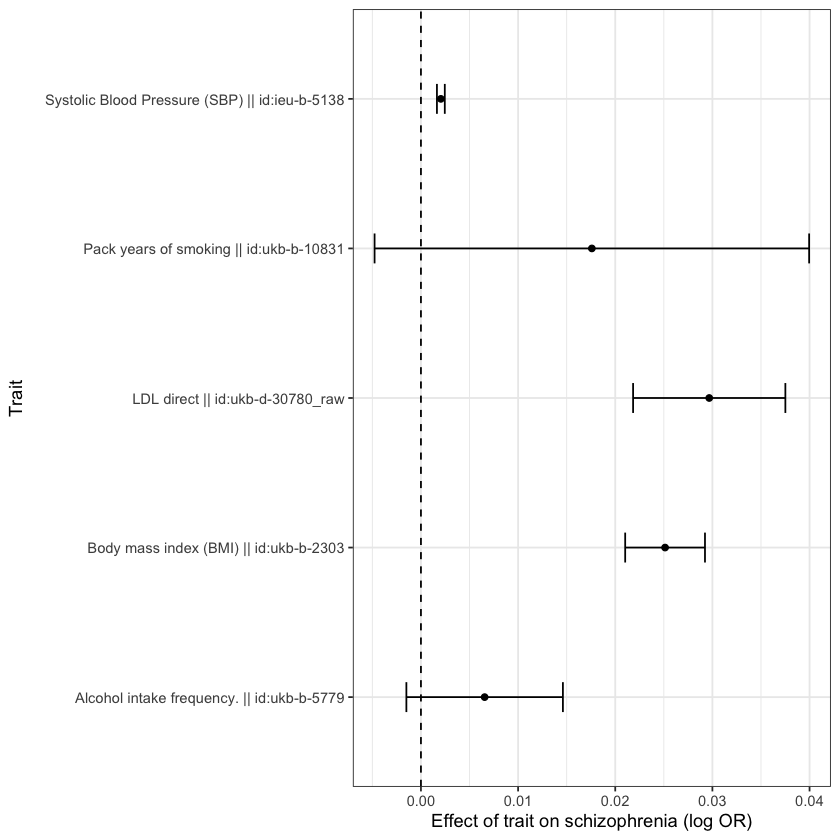

In [206]:
load("chd_phewas_result.Rdata")
dat1 <- harmonise_data(int_inst, outdat, action=1)
int_mr_res <- mr(dat1, method_list=c("mr_ivw", "mr_wald_ratio"))
int_mr_res %>% arrange(pval) %>% select(exposure, nsnp, b, se, pval)

int_mr_res %>% ggplot(., aes(x=b, y=exposure)) + geom_point() + geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0.2) + theme_bw() + geom_vline(xintercept = 0, linetype="dashed") + xlab("Effect of trait on schizophrenia (log OR)") + ylab("Trait")

In [207]:
dat2 <- dat1
dat2 <- add_metadata(dat2)
dat2 <- add_rsq(dat2)
str(dat2)
dat1 <- steiger_filtering(dat2)
table(dat1$steiger_dir)

'data.frame':	992 obs. of  55 variables:
 $ SNP                   : chr  "rs10029530" "rs10031363" "rs10160382" "rs10260816" ...
 $ effect_allele.exposure: chr  "T" "T" "C" "G" ...
 $ other_allele.exposure : chr  "A" "G" "T" "C" ...
 $ effect_allele.outcome : chr  "T" "T" "C" "G" ...
 $ other_allele.outcome  : chr  "A" "G" "T" "C" ...
 $ beta.exposure         : num  -0.337 -0.231 0.209 -0.32 -0.21 ...
 $ beta.outcome          : num  -0.001416 -0.00028 0.000114 0.001274 -0.000668 ...
 $ eaf.exposure          : num  0.66 0.595 0.346 0.44 0.54 ...
 $ eaf.outcome           : num  0.659 0.596 0.346 0.438 0.54 ...
 $ remove                : logi  FALSE FALSE FALSE FALSE FALSE FALSE ...
 $ palindromic           : logi  TRUE FALSE FALSE TRUE FALSE FALSE ...
 $ ambiguous             : logi  FALSE FALSE FALSE TRUE FALSE FALSE ...
 $ id.outcome            : chr  "ukb-d-I9_IHD" "ukb-d-I9_IHD" "ukb-d-I9_IHD" "ukb-d-I9_IHD" ...
 $ chr.outcome           : Factor w/ 84 levels "1","2","3","4",..: 4 4 1


FALSE  TRUE 
    4   988 

In [208]:
int_mr_res <- mr(dat1 %>% filter(steiger_dir), method_list=c("mr_ivw", "mr_wald_ratio"))
int_mr_res %>% arrange(pval) %>% select(exposure, nsnp, b, se, pval) %>% mutate(fdr = p.adjust(pval, method="fdr"))

Analysing 'ieu-b-5138' on 'ukb-d-I9_IHD'

Analysing 'ukb-b-2303' on 'ukb-d-I9_IHD'

Analysing 'ukb-b-5779' on 'ukb-d-I9_IHD'

Analysing 'ukb-b-10831' on 'ukb-d-I9_IHD'

Analysing 'ukb-d-30780_raw' on 'ukb-d-I9_IHD'



exposure,nsnp,b,se,pval,fdr
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Body mass index (BMI) || id:ukb-b-2303,446,0.025129858,0.0020951985,3.818998e-33,1.909499e-32
Systolic Blood Pressure (SBP) || id:ieu-b-5138,272,0.002114148,0.0001959025,3.761897e-27,9.404743e-27
LDL direct || id:ukb-d-30780_raw,157,0.030066783,0.0031896431,4.244920e-21,7.074867e-21
Alcohol intake frequency. || id:ukb-b-5779,97,0.008459347,0.0035208303,1.627645e-02,2.034557e-02
Pack years of smoking || id:ukb-b-10831,11,0.017592499,0.0114106842,1.231327e-01,1.231327e-01


In [209]:
# For each int trait, I need to get the CHD target SNPs that associate with it. Then for each target SNP-int pair I need to make two exposure datasets, one using the target SNP, the other using all other SNPs.
make_set <- function(int_chd, int_inst, chd) {
    dats <- lapply(1:nrow(int_chd), function(i) {
        snp <- int_chd$SNP[i]
        int <- int_chd$id.outcome[i]
        
        int_dat <- int_inst %>% filter(id.exposure == int)
        j <- which(chd$rsid == snp)
        target_region_dat <- int_dat %>%
            filter(chr.exposure == chd$chr[j] & abs(pos.exposure - chd$position[j]) < 1e6) %>%
            mutate(
                id.exposure = paste0("target - ", snp, id.exposure),
                exposure = paste0("target - ", snp, " - ", exposure)
            )
        
        other_region_dat <- subset(int_dat, !SNP %in% target_region_dat$SNP)
        
        bind_rows(other_region_dat, target_region_dat)
    })
    names(dats) <- paste(int_chd$SNP, int_chd$id.outcome, sep="_")
    dats
}

exp_sets <- make_set(int_chd, int_inst, chd)
str(exp_sets)

List of 23
 $ rs9349379_ieu-b-5138       :'data.frame':	285 obs. of  15 variables:
  ..$ id.exposure           : chr [1:285] "ieu-b-5138" "ieu-b-5138" "ieu-b-5138" "ieu-b-5138" ...
  ..$ chr.exposure          : chr [1:285] "5" "7" "4" "1" ...
  ..$ pos.exposure          : int [1:285] 32831939 106412082 81174592 11895795 90046518 100610546 18727959 104906211 11526765 164954174 ...
  ..$ SNP                   : chr [1:285] "rs12656497" "rs62481856" "rs13125101" "rs55857306" ...
  ..$ effect_allele.exposure: chr [1:285] "C" "A" "A" "A" ...
  ..$ other_allele.exposure : chr [1:285] "T" "G" "G" "G" ...
  ..$ eaf.exposure          : num [1:285] 0.596 0.197 0.292 0.162 0.829 ...
  ..$ beta.exposure         : num [1:285] 0.621 0.75 0.656 -0.752 0.683 ...
  ..$ se.exposure           : num [1:285] 0.037 0.0456 0.04 0.0492 0.0483 ...
  ..$ pval.exposure         : num [1:285] 4.4e-63 7.0e-61 2.0e-60 1.2e-52 2.0e-45 ...
  ..$ samplesize.exposure   : num [1:285] NA NA NA NA NA NA NA NA NA NA ...
  .

In [210]:
table(exp_sets[[1]]$exposure)


                     Systolic Blood Pressure (SBP) || id:ieu-b-5138 
                                                                284 
target - rs9349379 - Systolic Blood Pressure (SBP) || id:ieu-b-5138 
                                                                  1 

In [211]:
#' Cochran's Q test for heterogeneity
#' b: vector of effect estimates
#' se: vector of standard errors
cochran_q <- function(b, se) {
    w <- 1 / se^2
    q <- sum(w * (b - sum(w * b) / sum(w))^2)
    qpval <- pchisq(q, df=length(b)-1, lower.tail=FALSE)
    list(q=q, p=qpval)
}

res_sets <- lapply(exp_sets, function(exp_set) {
    dat <- harmonise_data(exp_set, outdat, action = 1)
    o <- mr(dat, method_list=c("mr_ivw", "mr_wald_ratio"))
    if(nrow(o) != 2) return(NULL)
    expname <- o$exposure[!grepl("target", o$exposure)]
    expname <- strsplit(expname, "\\|")[[1]][1]
    o$int_trait <- expname
    rsid <- o$exposure[grepl("target", o$exposure)] %>% {strsplit(., " - ")[[1]][2]}
    o$rsid <- rsid
    o$exposure[grepl(rsid, o$exposure)] <- rsid
    ind <- !grepl(rsid, o$exposure)
    o$exposure[ind] <- "All other SNPs"
    qres <- cochran_q(o$b, o$se)
    o$cochran_q <- qres$q
    o$cochran_p <- qres$p
    o$cochran_q[ind] <- 1
    o$cochran_p[ind] <- 1
    
    o
})

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (ieu-b-5138) and CHD (ukb-d-I9_IHD)

Removing the following SNPs for incompatible alleles:
rs17811915, rs34057719

Harmonising target - rs9349379 - Systolic Blood Pressure (SBP) || id:ieu-b-5138 (target - rs9349379ieu-b-5138) and CHD (ukb-d-I9_IHD)

Analysing 'ieu-b-5138' on 'ukb-d-I9_IHD'

Analysing 'target - rs9349379ieu-b-5138' on 'ukb-d-I9_IHD'

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (ieu-b-5138) and CHD (ukb-d-I9_IHD)

Removing the following SNPs for incompatible alleles:
rs17811915, rs34057719

Harmonising target - rs2107595 - Systolic Blood Pressure (SBP) || id:ieu-b-5138 (target - rs2107595ieu-b-5138) and CHD (ukb-d-I9_IHD)

Analysing 'ieu-b-5138' on 'ukb-d-I9_IHD'

Analysing 'target - rs2107595ieu-b-5138' on 'ukb-d-I9_IHD'

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (ieu-b-5138) and CHD (ukb-d-I9_IHD)

Removing the following SNPs for incompatible alleles:
rs17811915, rs34057719

Harm

`height` was translated to `width`.


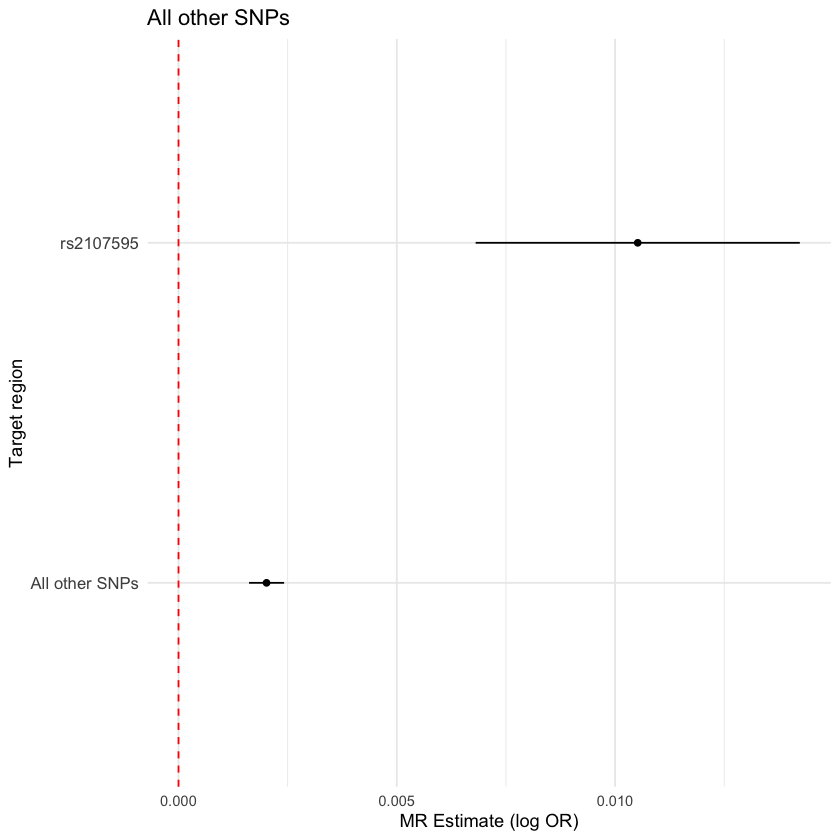

In [212]:
plot_one <- function(mr_result, title) {
    ggplot(mr_result, aes(x=b, y=exposure)) +
    geom_point() +
    geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se), height=0) +
    theme_minimal() +
    geom_vline(xintercept=0, linetype="dashed", color="red") +
    labs(x="MR Estimate (log OR)", y="Target region", title=title) +
    theme(axis.text.y = element_text(size=10))
}

plot_one(res_sets[[2]], res_sets[[1]]$exposure[1])


`height` was translated to `width`.


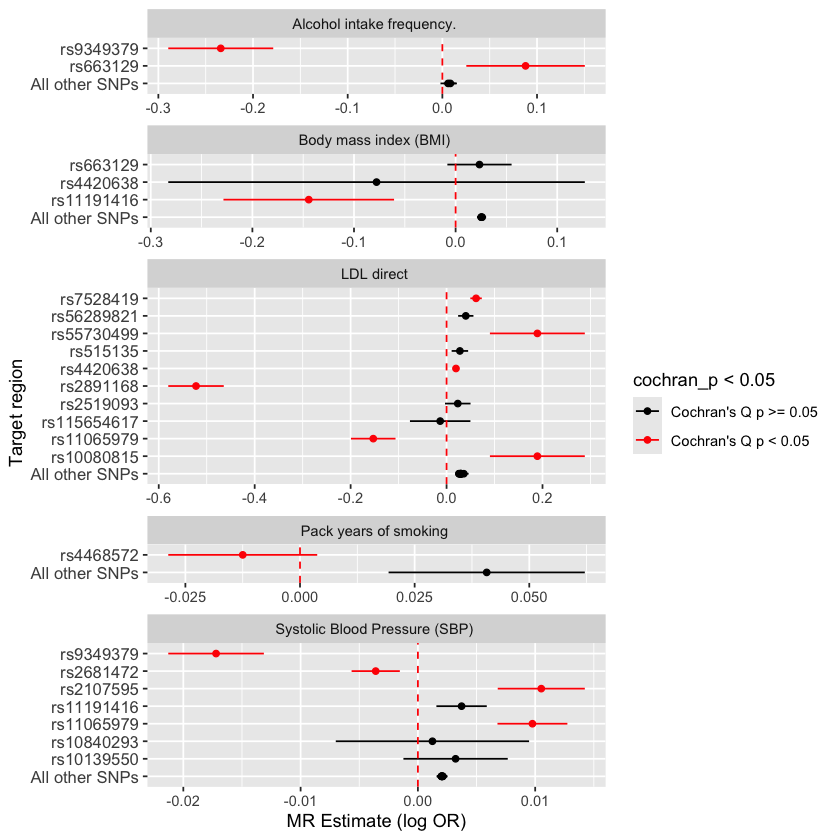

In [213]:
plot_int <- function(res_sets, int_id) {
    # keep mr_results that grepl int_name in the exposure name
    rs <- bind_rows(res_sets)
    ggplot(rs, aes(x=b, y=exposure)) +
    geom_point(aes(colour = cochran_p < 0.05)) +
    geom_errorbarh(aes(xmin=b-1.96*se, xmax=b+1.96*se, colour = cochran_p < 0.05), height=0) +
    geom_vline(xintercept=0, linetype="dashed", color="red") +
    labs(x="MR Estimate (log OR)", y="Target region") +
    facet_wrap(int_trait ~ ., scales = "free", ncol=1, space="free_y") +
    scale_colour_manual(values=c("black", "red"), labels=c("Cochran's Q p >= 0.05", "Cochran's Q p < 0.05")) +
    theme(axis.text.y = element_text(size=10))
}

plot_int(res_sets, sbpid)

In [214]:
table(int_chd$SNP %in% int_inst$SNP)
# str(int_inst)
int_chd2 <- int_chd
int_chd2$proxy <- NA
for(i in 1:nrow(int_chd)) {
    snp <- int_chd$SNP[i]
    chr <- chd$chr[which(chd$rsid == snp)]
    pos <- chd$position[which(chd$rsid == snp)]
    id <- int_chd$id.outcome[i]
    f <- subset(int_inst, id.exposure == id) %>%
    arrange(abs(pos.exposure - pos)) %>% slice_head(n=1)
    if(length(f$SNP) == 0) next
    int_chd2$proxy[i] <- f$SNP
}
print(as.data.frame(int_chd2))



FALSE  TRUE 
   21     2 

           SNP      id.outcome       proxy
1    rs9349379      ieu-b-5138   rs9349379
2    rs2107595      ieu-b-5138   rs7798197
3   rs11191416      ieu-b-5138  rs11191580
4   rs10840293      ieu-b-5138   rs1332796
5    rs2681472      ieu-b-5138  rs11431123
6   rs11065979      ieu-b-5138  rs10774625
7   rs10139550      ieu-b-5138  rs12050196
8    rs7528419 ukb-d-30780_raw  rs12740374
9     rs515135 ukb-d-30780_raw    rs581411
10 rs115654617 ukb-d-30780_raw   rs7569317
11  rs10080815 ukb-d-30780_raw   rs3127580
12  rs55730499 ukb-d-30780_raw rs118039278
13   rs2891168 ukb-d-30780_raw   rs6475606
14   rs2519093 ukb-d-30780_raw rs115478735
15  rs11065979 ukb-d-30780_raw    rs597808
16  rs56289821 ukb-d-30780_raw  rs12151108
17   rs4420638 ukb-d-30780_raw   rs1065853
18   rs4468572     ukb-b-10831   rs8042849
19   rs9349379      ukb-b-5779   rs9349379
20    rs663129      ukb-b-5779   rs4968391
21  rs11191416      ukb-b-2303   rs1436348
22    rs663129      ukb-b-2303  rs12967135
23   rs4420

In [ ]:
per_exposure_dat <- lapply(allintids, function(int_id) {
    print(int_id)
    d <- subset(dat1, id.exposure == int_id)
    chd_hits <- subset(int_chd2, id.outcome == int_id)
    print(chd_hits)
    mrs <- mr_singlesnp(d)
    mrs$chd_hit <- mrs$SNP %in% chd_hits$proxy
    mr_forest_plot(mrs)[[1]] + geom_point(data=subset(mrs, chd_hit), colour="red", shape = 19, size=4)
})

[1] "ieu-b-5138"
         SNP id.outcome      proxy
1  rs9349379 ieu-b-5138  rs9349379
2  rs2107595 ieu-b-5138  rs7798197
3 rs11191416 ieu-b-5138 rs11191580
4 rs10840293 ieu-b-5138  rs1332796
5  rs2681472 ieu-b-5138 rs11431123
6 rs11065979 ieu-b-5138 rs10774625
7 rs10139550 ieu-b-5138 rs12050196
[1] "ukb-d-30780_raw"
           SNP      id.outcome       proxy
8    rs7528419 ukb-d-30780_raw  rs12740374
9     rs515135 ukb-d-30780_raw    rs581411
10 rs115654617 ukb-d-30780_raw   rs7569317
11  rs10080815 ukb-d-30780_raw   rs3127580
12  rs55730499 ukb-d-30780_raw rs118039278
13   rs2891168 ukb-d-30780_raw   rs6475606
14   rs2519093 ukb-d-30780_raw rs115478735
15  rs11065979 ukb-d-30780_raw    rs597808
16  rs56289821 ukb-d-30780_raw  rs12151108
17   rs4420638 ukb-d-30780_raw   rs1065853
[1] "ukb-b-10831"
         SNP  id.outcome     proxy
18 rs4468572 ukb-b-10831 rs8042849
[1] "ukb-b-5779"
         SNP id.outcome     proxy
19 rs9349379 ukb-b-5779 rs9349379
20  rs663129 ukb-b-5779 rs4968391
[

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


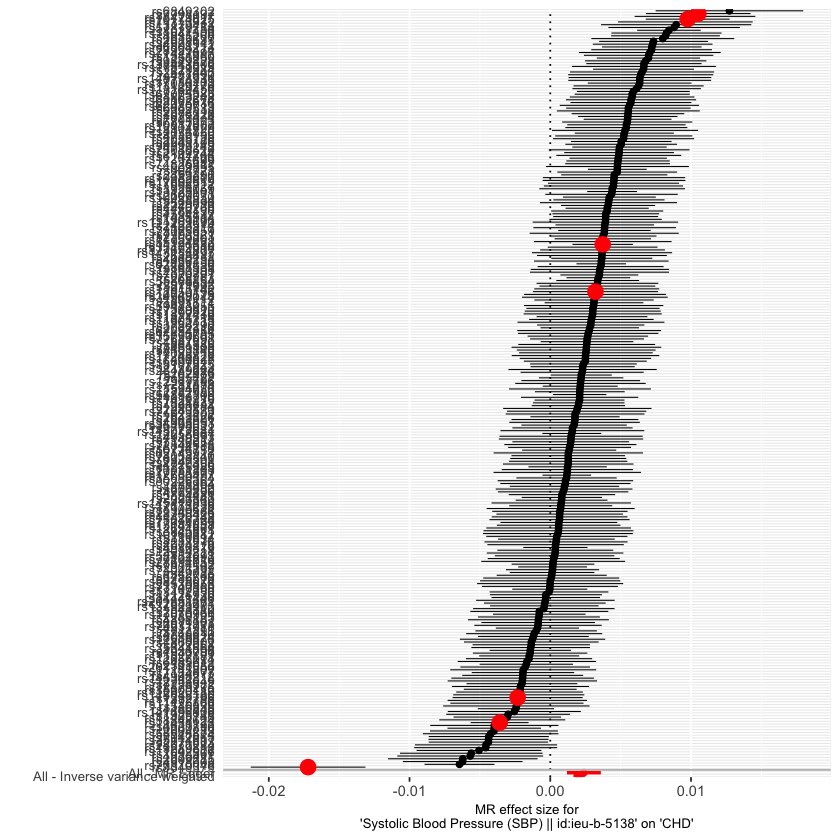

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


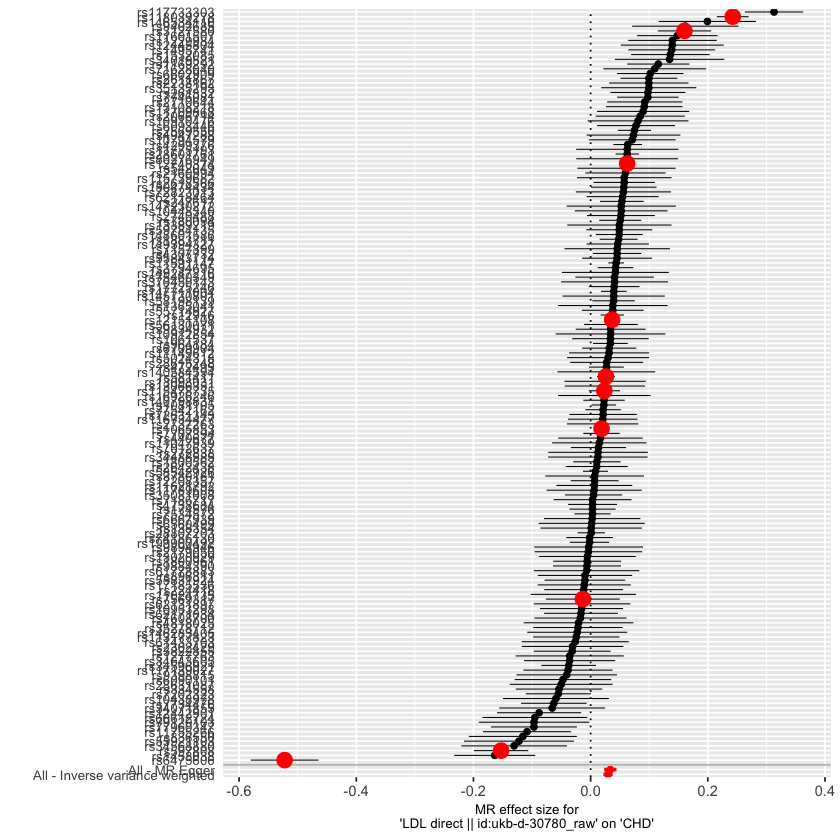

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


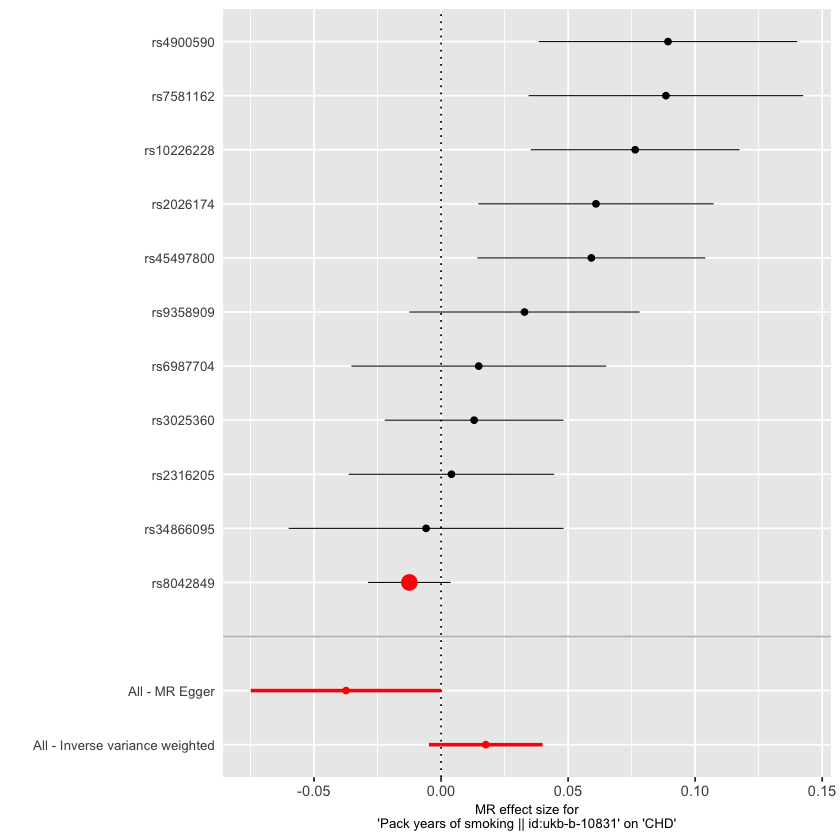

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


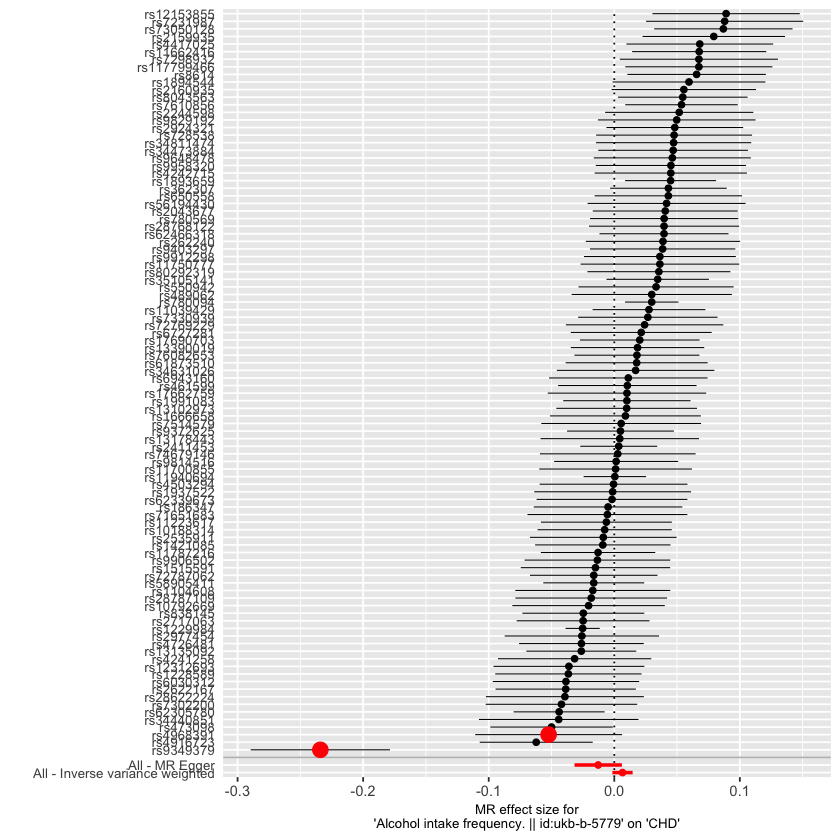

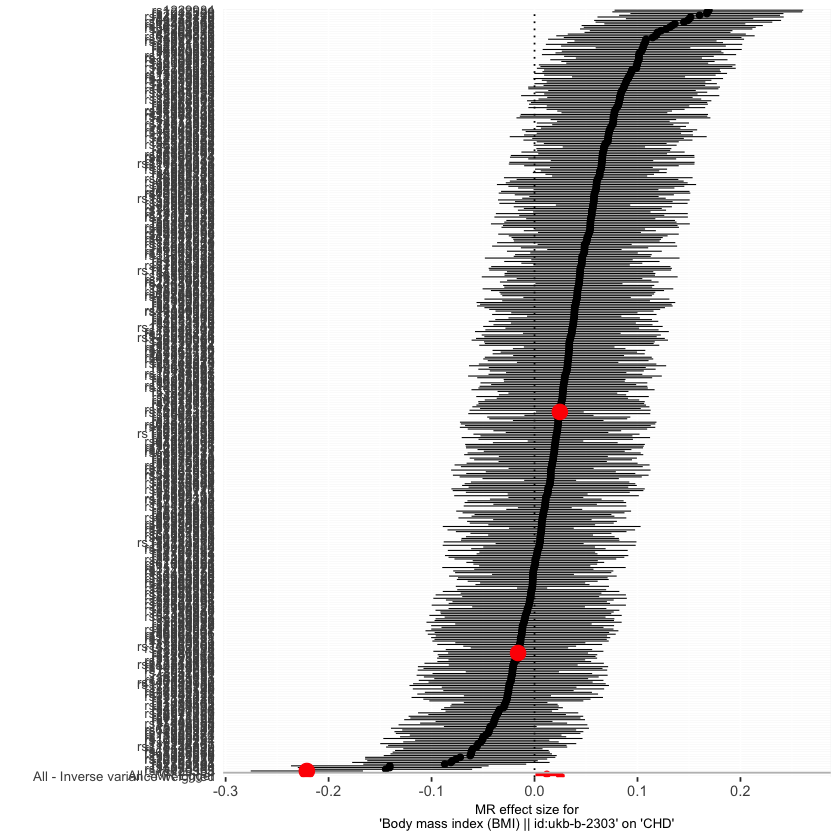

In [216]:
per_exposure_dat

In [112]:
dat1 %>% str

'data.frame':	992 obs. of  57 variables:
 $ SNP                   : chr  "rs10029530" "rs10031363" "rs10160382" "rs10260816" ...
 $ effect_allele.exposure: chr  "T" "T" "C" "G" ...
 $ other_allele.exposure : chr  "A" "G" "T" "C" ...
 $ effect_allele.outcome : chr  "T" "T" "C" "G" ...
 $ other_allele.outcome  : chr  "A" "G" "T" "C" ...
 $ beta.exposure         : num  -0.337 -0.231 0.209 -0.32 -0.21 ...
 $ beta.outcome          : num  -0.001416 -0.00028 0.000114 0.001274 -0.000668 ...
 $ eaf.exposure          : num  0.66 0.595 0.346 0.44 0.54 ...
 $ eaf.outcome           : num  0.659 0.596 0.346 0.438 0.54 ...
 $ remove                : logi  FALSE FALSE FALSE FALSE FALSE FALSE ...
 $ palindromic           : logi  TRUE FALSE FALSE TRUE FALSE FALSE ...
 $ ambiguous             : logi  FALSE FALSE FALSE TRUE FALSE FALSE ...
 $ id.outcome            : chr  "ukb-d-I9_IHD" "ukb-d-I9_IHD" "ukb-d-I9_IHD" "ukb-d-I9_IHD" ...
 $ chr.outcome           : Factor w/ 84 levels "1","2","3","4",..: 4 4 1

In [217]:
str(chd)
str(int_chd)

tibble [41 × 12] (S3: tbl_df/tbl/data.frame)
 $ id      : chr [1:41] "ieu-a-7" "ieu-a-7" "ieu-a-7" "ieu-a-7" ...
 $ trait   : chr [1:41] "Coronary heart disease" "Coronary heart disease" "Coronary heart disease" "Coronary heart disease" ...
 $ chr     : chr [1:41] "9" "6" "6" "1" ...
 $ position: int [1:41] 22098619 12903957 161005610 109817192 203893999 79124475 160687412 35593827 11188247 44480811 ...
 $ rsid    : chr [1:41] "rs2891168" "rs9349379" "rs55730499" "rs7528419" ...
 $ ea      : chr [1:41] "G" "G" "T" "G" ...
 $ nea     : chr [1:41] "A" "A" "C" "A" ...
 $ eaf     : num [1:41] 0.4887 0.4316 0.0562 0.2142 0.107 ...
 $ beta    : num [1:41] 0.193 0.132 0.317 -0.115 0.138 ...
 $ se      : num [1:41] 0.00919 0.00965 0.02424 0.01148 0.01583 ...
 $ p       : num [1:41] 2.29e-98 1.81e-42 5.39e-39 1.97e-23 3.12e-18 ...
 $ n       : num [1:41] 184305 184305 184305 184305 184305 ...
'data.frame':	23 obs. of  2 variables:
 $ SNP       : chr  "rs9349379" "rs2107595" "rs11191416" "rs1084

In [218]:
generate_q_dist <- function(temp, outdat) {
    lapply(1:nrow(temp), function(i) {
        temp2 <- temp
        temp2$id.exposure[i] <- "target"
        dat <- harmonise_data(temp2, outdat, action = 1)
        o <- mr(dat, method_list=c("mr_ivw", "mr_wald_ratio"))
        if(nrow(o) != 2) return(NULL)
        tibble(
            q = cochran_q(o$b, o$se)$q,
            type = temp$type[i],
            snp = temp$SNP[i]
        )
    }) %>% bind_rows()
}

int_id <- allintids[1]
qdist_res <- lapply(allintids, function(int_id) {
    temp <- int_inst %>% filter(id.exposure == int_id) %>% mutate(type = "background")
    temp2 <- subset(chd, rsid %in% int_chd$SNP[int_chd$id.outcome == int_id])
    for(i in 1:nrow(temp2)) {
        j <- which(temp$chr == temp2$chr[i] & abs(temp$pos.exposure - temp2$position[i]) < 1e6)
        temp$type[j] <- "chd hit"
    }
    generate_q_dist(temp, outdat) %>% mutate(int_id = int_id)
}) %>% bind_rows()


Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (ieu-b-5138) and CHD (ukb-d-I9_IHD)

Removing the following SNPs for incompatible alleles:
rs17811915, rs34057719

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (target) and CHD (ukb-d-I9_IHD)

Analysing 'ieu-b-5138' on 'ukb-d-I9_IHD'

Analysing 'target' on 'ukb-d-I9_IHD'

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (ieu-b-5138) and CHD (ukb-d-I9_IHD)

Removing the following SNPs for incompatible alleles:
rs17811915, rs34057719

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (target) and CHD (ukb-d-I9_IHD)

Analysing 'ieu-b-5138' on 'ukb-d-I9_IHD'

Analysing 'target' on 'ukb-d-I9_IHD'

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (ieu-b-5138) and CHD (ukb-d-I9_IHD)

Removing the following SNPs for incompatible alleles:
rs17811915, rs34057719

Harmonising Systolic Blood Pressure (SBP) || id:ieu-b-5138 (target) and CHD (ukb-d-I9_IHD)

Analysing 'ieu-b-5138' on 'ukb-d-I9_IHD'



In [219]:
table(qdist_res$type)


background    chd hit 
       945         42 

In [220]:
gi <- gwasinfo(allintids)
qdist_res <- inner_join(qdist_res, gi %>% select(id, trait), by=c("int_id"="id"))

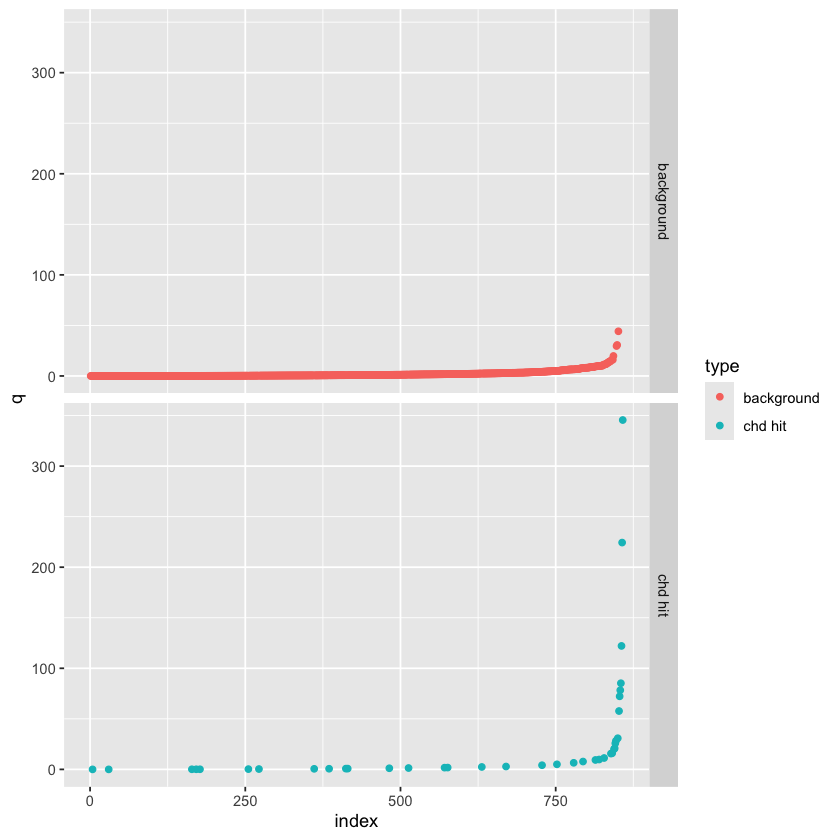

In [199]:
qdist_res %>%
    arrange(q) %>%
    mutate(index=1:n()) %>%
    ggplot(., aes(x=index, y=q, colour=type)) +
    geom_point() +
    facet_grid(type ~ .)

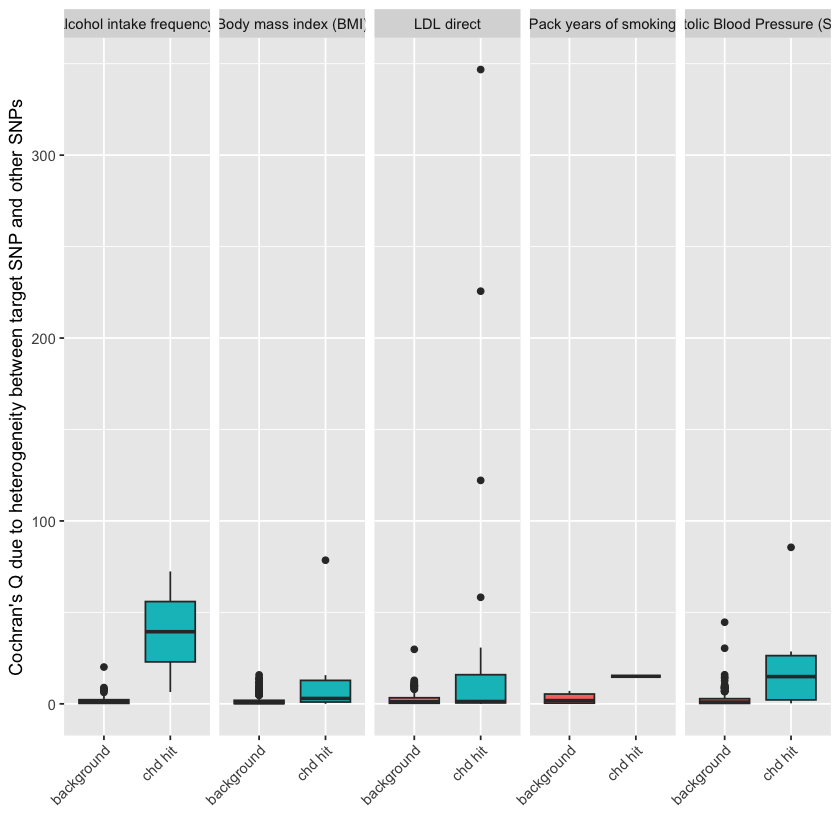

In [221]:
    
    ggplot(qdist_res, aes(x=type, y=q, fill=type)) +
    geom_boxplot() +
    facet_grid(. ~ trait) +
    theme(legend.position="none", axis.text.x = element_text(angle=45, hjust=1)) +
    labs(x="", y="Cochran's Q due to heterogeneity between target SNP and other SNPs")

In [222]:
int_chd

SNP,id.outcome
<chr>,<chr>
rs9349379,ieu-b-5138
rs2107595,ieu-b-5138
rs11191416,ieu-b-5138
rs10840293,ieu-b-5138
rs2681472,ieu-b-5138
rs11065979,ieu-b-5138
rs10139550,ieu-b-5138
rs7528419,ukb-d-30780_raw
rs515135,ukb-d-30780_raw


In [201]:
vi <- ieugwasr::variants_rsid(unique(int_chd2$SNP))
str(vi)

tibble [18 × 5] (S3: tbl_df/tbl/data.frame)
 $ query       : chr [1:18] "rs515135" "rs663129" "rs2107595" "rs2519093" ...
 $ name        : chr [1:18] "rs515135" "rs663129" "rs2107595" "rs2519093" ...
 $ chr         : chr [1:18] "2" "18" "7" "9" ...
 $ pos         : int [1:18] 21286057 57838401 19049388 136141870 90008959 22098619 45422946 79124475 109817192 12903957 ...
 $ dbSNPBuildID: int [1:18] 157 157 157 157 157 157 157 157 157 157 ...


In [180]:
library(gpmapr)
int_genes <- lapply(int_chd$SNP, \(x) {
# x <- "rs11191416"
    print(x)
    v <- variants(x)
    print(str(v))
    prox <- ld_proxies(v$variants$id)
    print(head(prox))
    res <- gpmapr::variant(prox$lead_variant_id[1])
    genes <- res$coloc_group$gene
    genes <- genes[!is.na(genes)]
    if(length(genes) == 0) {
        o <- tibble(SNP = x, gene = v$symbol[1])
    } else {
        o <- tibble(gene = genes) %>% group_by(gene) %>% summarise(n=n()) %>% ungroup() %>% arrange(desc(n)) %>% slice_head(n=1) %>% mutate(SNP = x) %>% select(SNP, gene)
    }
    print(o)
    return(o)
}) %>% bind_rows()
int_genes

[1] "rs9349379"
List of 1
 $ variants:'data.frame':	1 obs. of  33 variables:
  ..$ id                           : int 7696823
  ..$ snp                          : chr "6:12903725_A_G"
  ..$ display_snp                  : chr "6:12903725 A/G"
  ..$ chr                          : int 6
  ..$ bp                           : int 12903725
  ..$ ea                           : chr "G"
  ..$ oa                           : chr "A"
  ..$ ref_allele                   : chr "A"
  ..$ flipped                      : logi TRUE
  ..$ gene_id                      : logi NA
  ..$ gene                         : chr "ENSG00000112137"
  ..$ feature_type                 : chr "Transcript"
  ..$ consequence                  : chr "intron_variant"
  ..$ cdna_position                : chr "-"
  ..$ cds_position                 : chr "-"
  ..$ protein_position             : chr "-"
  ..$ amino_acids                  : chr "-"
  ..$ codons                       : chr "-"
  ..$ rsid                         : chr "

ERROR: Error in gpmapr::variant(prox$lead_variant_id[1]): variant_id is required


In [173]:
variants("rs11191416")

,id,snp,display_snp,chr,bp,ea,oa,ref_allele,flipped,gene_id,⋯,canonical,all_af,eur_af,eas_af,amr_af,afr_af,sas_af,distinct_trait_categories,distinct_protein_coding_genes,associations
,<int>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<lgl>,<int>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>
1,1142635,10:102845159_G_T,10:102845159 T/G,10,102845159,G,T,T,FALSE,38459,⋯,YES,0.1809,0.0924,0.2017,0.3482,0.2587,0.0522,NA,NA,NA


In [179]:
ld_proxies(1142635)

,lead_variant_id,proxy_variant_id,ld_block_id,r
,<int>,<int>,<int>,<dbl>
1,1142986,1142635,857,0.923700
2,1143555,1142635,857,0.909035
3,1143706,1142635,857,0.902799


Can it be explained by reverse cause

In [225]:
chd_inst <- extract_instruments("ieu-a-7")
# chd_inst2 <- extract_instruments("ukb-d-I9_IHD")


med_out <- lapply(allintids, \(x) {
    message(x)
    a <- query_gwas(rsid = chd$rsid, vcf = paste0(x, ".vcf.gz")) %>% gwasvcf_to_TwoSampleMR(., type="outcome")
    a
}) %>% bind_rows()
med_out <- med_out %>% select(-c(outcome))
med_out <- inner_join(med_out, gi %>% select(id, outcome=trait), by=c("id.outcome"="id"))
rev_dat <- harmonise_data(chd_inst, med_out, action=1)
str(rev_dat)

ieu-b-5138

ukb-d-30780_raw

ukb-b-10831

ukb-b-5779

ukb-b-2303

Harmonising Coronary heart disease || id:ieu-a-7 (ieu-a-7) and Systolic Blood Pressure (SBP) (ieu-b-5138)

Harmonising Coronary heart disease || id:ieu-a-7 (ieu-a-7) and Pack years of smoking (ukb-b-10831)

Harmonising Coronary heart disease || id:ieu-a-7 (ieu-a-7) and Body mass index (BMI) (ukb-b-2303)

Harmonising Coronary heart disease || id:ieu-a-7 (ieu-a-7) and Alcohol intake frequency. (ukb-b-5779)

Harmonising Coronary heart disease || id:ieu-a-7 (ieu-a-7) and LDL direct (ukb-d-30780_raw)



'data.frame':	198 obs. of  36 variables:
 $ SNP                   : chr  "rs10080815" "rs10139550" "rs10840293" "rs11065979" ...
 $ effect_allele.exposure: chr  "G" "G" "A" "T" ...
 $ other_allele.exposure : chr  "T" "C" "G" "C" ...
 $ effect_allele.outcome : chr  "G" "G" "A" "T" ...
 $ other_allele.outcome  : chr  "T" "C" "G" "C" ...
 $ beta.exposure         : num  0.2466 0.0554 0.0547 0.0686 -0.0792 ...
 $ beta.outcome          : num  0.238 0.203 0.276 0.318 -0.754 ...
 $ eaf.exposure          : num  0.0276 0.423 0.5498 0.3655 0.1275 ...
 $ eaf.outcome           : num  0.0197 0.4226 0.5594 0.4379 0.0847 ...
 $ remove                : logi  FALSE FALSE FALSE FALSE FALSE FALSE ...
 $ palindromic           : logi  FALSE TRUE FALSE FALSE FALSE FALSE ...
 $ ambiguous             : logi  FALSE TRUE FALSE FALSE FALSE FALSE ...
 $ id.outcome            : chr  "ieu-b-5138" "ieu-b-5138" "ieu-b-5138" "ieu-b-5138" ...
 $ chr.outcome           : Factor w/ 84 levels "1","2","3","4",..: 6 14 11 12 

In [226]:
mr(rev_dat, method_list=c("mr_ivw", "mr_wald_ratio"))

Analysing 'ieu-a-7' on 'ieu-b-5138'

Analysing 'ieu-a-7' on 'ukb-b-10831'

Analysing 'ieu-a-7' on 'ukb-b-2303'

Analysing 'ieu-a-7' on 'ukb-b-5779'

Analysing 'ieu-a-7' on 'ukb-d-30780_raw'



id.exposure,id.outcome,outcome,exposure,method,nsnp,b,se,pval
<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ieu-a-7,ieu-b-5138,Systolic Blood Pressure (SBP),Coronary heart disease || id:ieu-a-7,Inverse variance weighted,41,0.56133749,0.32361126,0.082810918
ieu-a-7,ukb-b-10831,Pack years of smoking,Coronary heart disease || id:ieu-a-7,Inverse variance weighted,39,-0.02802102,0.01001169,0.005128803
ieu-a-7,ukb-b-2303,Body mass index (BMI),Coronary heart disease || id:ieu-a-7,Inverse variance weighted,39,-0.01248287,0.01903943,0.512060575
ieu-a-7,ukb-b-5779,Alcohol intake frequency.,Coronary heart disease || id:ieu-a-7,Inverse variance weighted,39,-0.02484496,0.01224165,0.042402915
ieu-a-7,ukb-d-30780_raw,LDL direct,Coronary heart disease || id:ieu-a-7,Inverse variance weighted,40,0.11850562,0.06424016,0.065077099


[1] "ieu-b-5138"
[1] "ukb-d-30780_raw"
[1] "ukb-b-10831"
[1] "ukb-b-5779"
[1] "ukb-b-2303"


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


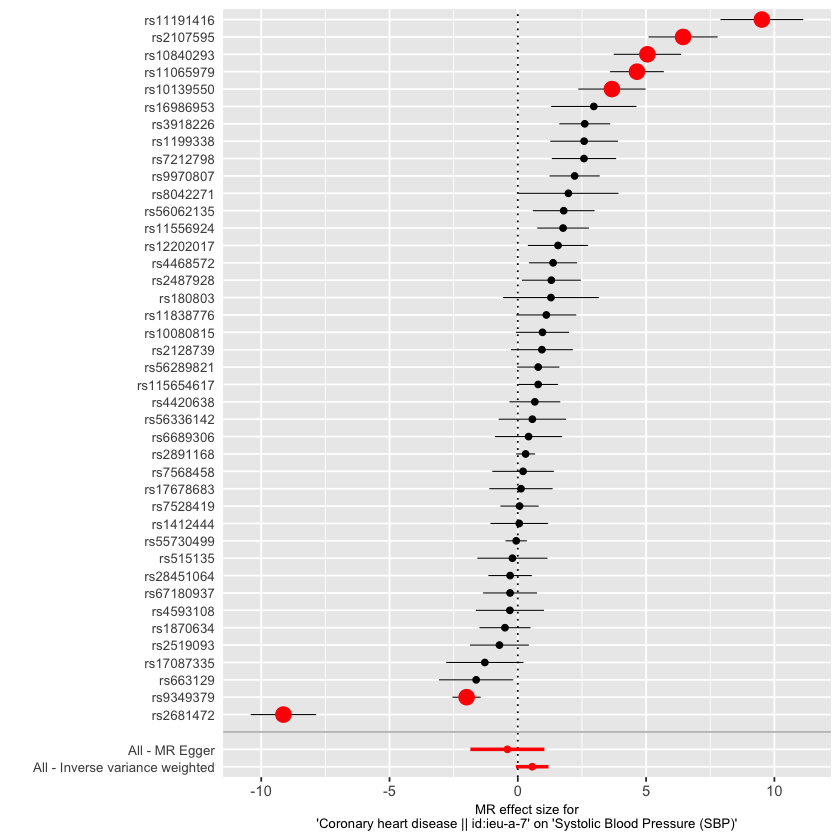

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


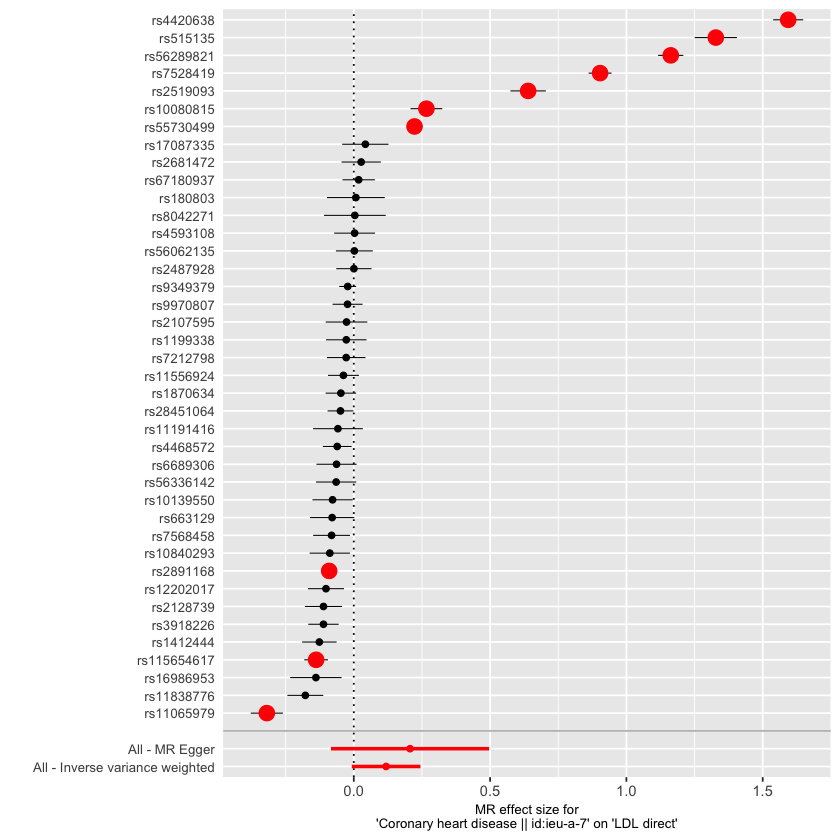

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


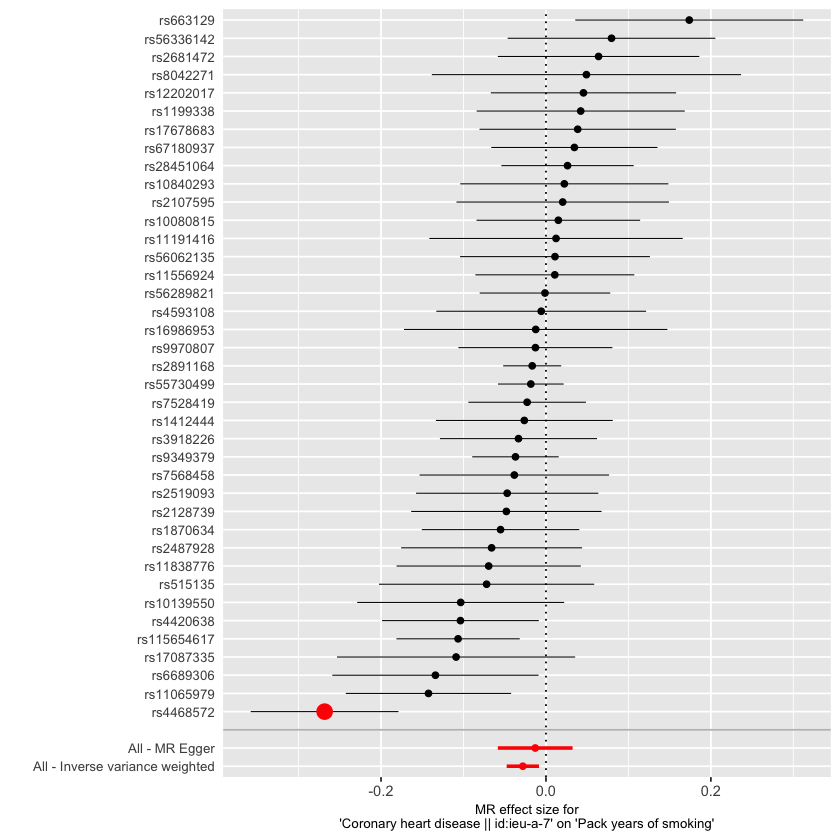

Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


[[1]]

[[2]]

[[3]]

[[4]]

[[5]]


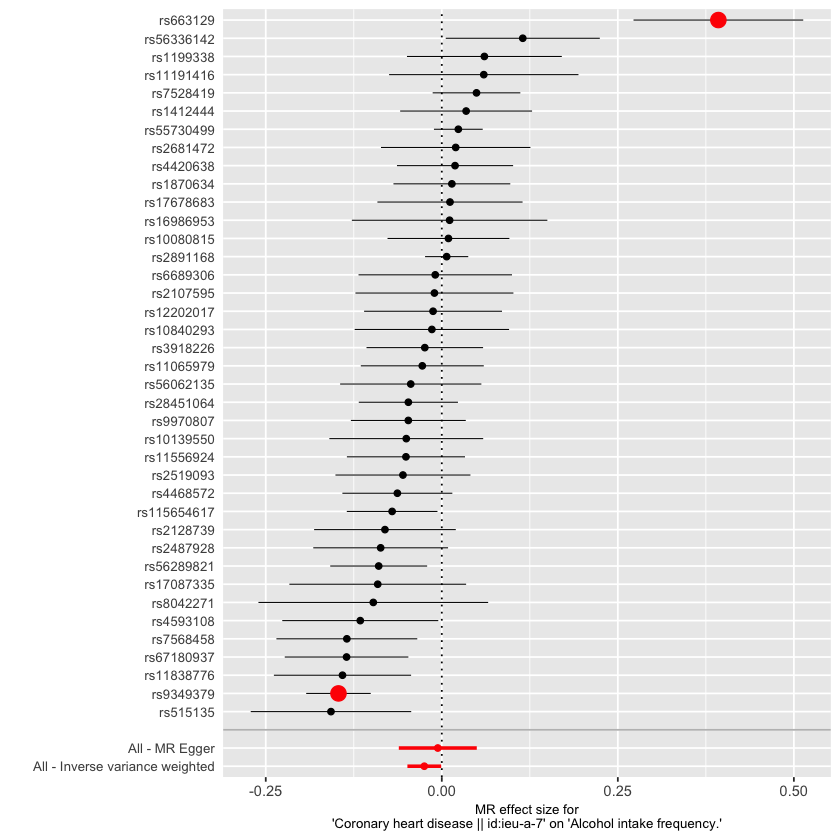

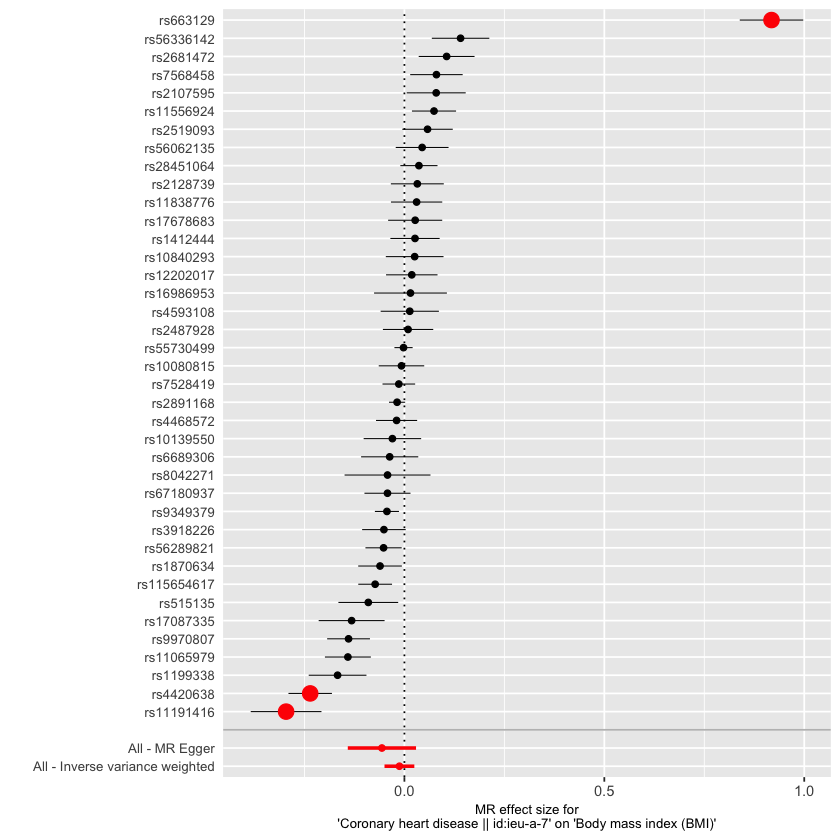

In [233]:
rev_mrs <- mr_singlesnp(rev_dat)
rev_mrs$chd_hit <- paste(rev_mrs$SNP, rev_mrs$id.outcome) %in% paste(int_chd$SNP, int_chd$id.outcome)
lapply(1:length(allintids), function(i) {
    int_id <- allintids[i]
    print(int_id)
    mr_forest_plot(subset(rev_mrs, id.outcome == int_id))[[1]] + geom_point(data=subset(rev_mrs, chd_hit & id.outcome == int_id), colour="red", shape = 19, size=4)
})

In [227]:
table(int_chd$SNP %in% int_inst$SNP)
# str(int_inst)
int_chd2 <- int_chd
int_chd2$proxy <- NA
for(i in 1:nrow(int_chd)) {
    snp <- int_chd$SNP[i]
    chr <- chd$chr[which(chd$rsid == snp)]
    pos <- chd$position[which(chd$rsid == snp)]
    id <- int_chd$id.outcome[i]
    f <- subset(int_inst, id.exposure == id) %>%
    arrange(abs(pos.exposure - pos)) %>% slice_head(n=1)
    if(length(f$SNP) == 0) next
    int_chd2$proxy[i] <- f$SNP
}
print(as.data.frame(int_chd2))



FALSE  TRUE 
   21     2 

           SNP      id.outcome       proxy
1    rs9349379      ieu-b-5138   rs9349379
2    rs2107595      ieu-b-5138   rs7798197
3   rs11191416      ieu-b-5138  rs11191580
4   rs10840293      ieu-b-5138   rs1332796
5    rs2681472      ieu-b-5138  rs11431123
6   rs11065979      ieu-b-5138  rs10774625
7   rs10139550      ieu-b-5138  rs12050196
8    rs7528419 ukb-d-30780_raw  rs12740374
9     rs515135 ukb-d-30780_raw    rs581411
10 rs115654617 ukb-d-30780_raw   rs7569317
11  rs10080815 ukb-d-30780_raw   rs3127580
12  rs55730499 ukb-d-30780_raw rs118039278
13   rs2891168 ukb-d-30780_raw   rs6475606
14   rs2519093 ukb-d-30780_raw rs115478735
15  rs11065979 ukb-d-30780_raw    rs597808
16  rs56289821 ukb-d-30780_raw  rs12151108
17   rs4420638 ukb-d-30780_raw   rs1065853
18   rs4468572     ukb-b-10831   rs8042849
19   rs9349379      ukb-b-5779   rs9349379
20    rs663129      ukb-b-5779   rs4968391
21  rs11191416      ukb-b-2303   rs1436348
22    rs663129      ukb-b-2303  rs12967135
23   rs4420